# Splicing Model Evaluation

In [22]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [2]:
from alphagenome_pytorch.plotting.splicing import (
    plot_splice_site_dynamics,
    plot_splice_site_predictions,
    plot_usage_density,
    SPLICE_CLASS_NAMES,
    BACKGROUND_CLASS,
    CLASS_LABELS,
    CLASS_COLORS,
    TISSUE_COLORS,
    TISSUE_ORDER,
    SPECIES_ORDER,
    SPECIES,
    SPECIES_SCI,
    CHR_SIZES,
)
from alphagenome_pytorch.evaluation.splicing import (
    load_splice_predictions,
    load_splice_usage_stats,
)

In [ ]:
home = os.path.expanduser("~")
work_dir = f"{home}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/"
ann_data_dir = f"{home}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/"
model = "lora_32_traj_human_mouse_rat_rabbit_opossum_sasse3"
model_dir = os.path.join(work_dir, model)

subsets = ["intersect_protein_coding"]  # "intersect_usage", "intersect_protein_coding", "gtf_protein_coding"
subset = subsets[0]
pred_dir = f"preds_{subset}"
conf_fn = f"data_config_{subset}.json"
data_config_path = os.path.join(ann_data_dir, conf_fn)
data_config = json.load(open(data_config_path, "r"))

## Evaluation

### Splice site classification

#### Evaluate model predictions

In [4]:
evals = load_splice_predictions(model_dir, subsets=subsets, species_list=SPECIES_ORDER)

Loading predictions from /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_traj_human_mouse_rat_rabbit_opossum_sasse3/preds_intersect_protein_coding
Predictions for opossum in preds_intersect_protein_coding are missing.
Predictions for chicken in preds_intersect_protein_coding are missing.


Plot AUPRC per class for each species (rows) and subset of sites (columns).

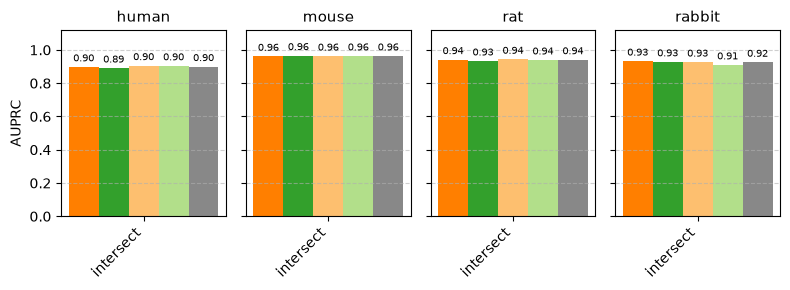

In [5]:
class_keys = SPLICE_CLASS_NAMES + ["binary"]
species_plot = [s for s in SPECIES_ORDER if s in evals]
if subsets is None:
    subset_plot = ["preds"]
else:
    subset_keys = ["preds_" + s for s in subsets]
    subset_plot = [s for s in subset_keys if any(evals[sp].get(s) is not None for sp in species_plot)]
annot_bars = True

fig, axes = plt.subplots(
    1, len(species_plot),
    figsize=(max(len(species_plot) * 2, 4), 3),
    sharey=True,
    squeeze=False
)

axes = axes[0]

x_subset = np.arange(len(subset_plot))
bar_width = 0.9 / max(len(class_keys), 1)
class_colors = [CLASS_COLORS[i] for i in range(len(SPLICE_CLASS_NAMES))] + ["#888888"]

for ax, sp in zip(axes, species_plot):
    for j, class_key in enumerate(class_keys):
        values = []
        counts = []

        for subset in subset_plot:
            subset_data = evals.get(sp, {}).get(subset, {})
            auprc_map = subset_data.get("auprc", {}) if subset_data is not None else {}
            site_map = subset_data.get("sites", {}) if subset_data is not None else {}

            values.append(auprc_map.get(class_key, np.nan))

            if class_key == "binary":
                cls_counts = [site_map.get(k, np.nan) for k in SPLICE_CLASS_NAMES]
                n_sites = np.nansum(cls_counts) if len(cls_counts) else np.nan
            else:
                n_sites = site_map.get(class_key, np.nan)
            counts.append(n_sites)

        offsets = x_subset + (j - (len(class_keys) - 1) / 2) * bar_width
        bars = ax.bar(offsets, values, width=bar_width, color=class_colors[j], label=class_key)

        if annot_bars:
            for bar, n, v in zip(bars, counts, values):
                if np.isfinite(v):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        min(v + 0.02, 1.08),
                        f"{v:.2f}",
                        ha="center",
                        va="bottom",
                        fontsize=7
                    )

    ax.set_title(sp, fontsize=11)
    ax.set_xticks(x_subset)
    ax.set_xticklabels([s.replace("preds_", "").replace("_protein_coding", "").replace("intersect_usage", "usage") for s in subset_plot], rotation=45, ha="right")
    ax.set_ylim(0, 1.12)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

axes[0].set_ylabel("AUPRC")

plt.tight_layout()

fig.savefig(
    os.path.join(work_dir, model, "prediction_splice_site_auprc_by_subset_grouped.png"),
    dpi=300,
    bbox_inches="tight"
)

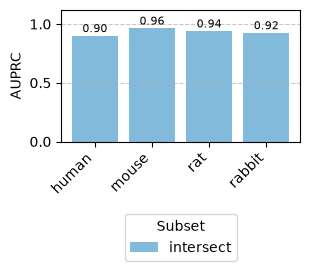

In [6]:
class_keys = SPLICE_CLASS_NAMES  # exclude binary
species_plot = [s for s in SPECIES_ORDER if s in evals]
if subsets is None:
    subset_plot = ["preds"]
else:
    subset_keys = ["preds_" + s for s in subsets]
    subset_plot = [s for s in subset_keys if any(evals[sp].get(s) is not None for sp in species_plot)]

fig, ax = plt.subplots(figsize=(len(species_plot) * 0.8, 3.5))

x_species = np.arange(len(species_plot))
bar_width = 0.8 / max(len(subset_plot), 1)

for si, subset in enumerate(subset_plot):
    values = []
    for sp in species_plot:
        subset_data = evals.get(sp, {}).get(subset, {})
        auprc_map = subset_data.get("auprc", {}) if subset_data else {}
        class_vals = [auprc_map.get(k, np.nan) for k in class_keys]
        mean_val = np.nanmean(class_vals) if any(np.isfinite(v) for v in class_vals) else np.nan
        values.append(mean_val)
    

    offsets = x_species + (si - (len(subset_plot) - 1) / 2) * bar_width
    # colors = shades of blue
    bars = ax.bar(offsets, values, width=bar_width, label=subset, alpha=0.85, color=sns.color_palette("Blues_r", n_colors=len(subset_plot))[si])

    for bar, v in zip(bars, values):
        if np.isfinite(v):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                v + 0.01,
                f"{v:.2f}",
                ha="center", va="bottom", fontsize=8
            )

ax.set_xticks(x_species)
ax.set_xticklabels(species_plot, rotation=45, ha="right")
ax.set_ylabel("AUPRC")
ax.set_ylim(0, 1.12)
ax.grid(axis="y", linestyle="--", alpha=0.7)


# legend outside below plot
ax.legend(
    [s.replace("preds_", "").replace("_protein_coding", "").replace("intersect_usage", "usage") for s in subset_plot],
    title="Subset", bbox_to_anchor=(0.5, -0.5), loc="upper center", ncol=len(subset_plot)
)

plt.tight_layout()
fig.savefig(
    os.path.join(work_dir, model, "prediction_splice_site_mean_auprc_by_species.png"),
    dpi=300, bbox_inches="tight"
)


#### Compare all models predictions

In [7]:
models_to_compare = [
    "132kb_encode_intersect_usage_pc_obs_human",
    "132kb_encode_intersect_usage_pc_obs_human_mouse",
    "132kb_encode_intersect_usage_pc_obs_human_mouse_rat",
    "132kb_encode_intersect_usage_pc_obs_human_mouse_rat_rabbit",
    "132kb_encode_intersect_usage_pc_obs_human_mouse_rat_rabbit_opossum",
    "132kb_encode_intersect_usage_pc_traj_human_mouse_rat_rabbit_opossum",
    "ft_human_mouse_rat_rabbit_opossum",
    "lora_32_human_mouse_rat_rabbit_opossum"
]
models_to_compare = []

subsets_to_compare = ["intersect_protein_coding"]

pov_model = model
pov_first = True

# only run if models_to_compare is not empty
if len(models_to_compare) > 0:

    evals_2_dict = {}
    for model_ in models_to_compare:
        if model_ == pov_model:
            continue
        model_dir_ = os.path.join(work_dir, model_)
        evals_ = load_splice_predictions(model_dir_, subsets_to_compare)
        evals_2_dict[model_] = evals_

    class_keys = SPLICE_CLASS_NAMES + ["binary"]
    model_2_names = list(evals_2_dict.keys())
    n_models2 = len(model_2_names)

    species_plot = [s for s in SPECIES_ORDER
                    if s in evals and any(s in ev for ev in evals_2_dict.values())]
    if subsets_to_compare is None:
        subset_plot = ["preds"]
    else:
        subset_keys = ["preds_" + s for s in subsets_to_compare]
        subset_plot = [s for s in subset_keys
                    if any(s in evals.get(sp, {}) for sp in species_plot)]

    # Collect all deltas for symmetric y-limit
    all_deltas = []
    for m2_name, evals_2 in evals_2_dict.items():
        for sp in species_plot:
            for subset in subset_plot:
                a1 = evals.get(sp, {}).get(subset, {}).get("auprc", {})
                a2 = evals_2.get(sp, {}).get(subset, {}).get("auprc", {})
                for k in class_keys:
                    v1, v2 = a1.get(k, np.nan), a2.get(k, np.nan)
                    if np.isfinite(v1) and np.isfinite(v2):
                        all_deltas.append(v1 - v2 if pov_first else v2 - v1)
    ylim = max(0.02, np.nanmax(np.abs(all_deltas)) * 1.15) if all_deltas else 0.05
    ylim_min, ylim_max = -ylim, ylim

    # Fixed limits if desired
    ylim_min, ylim_max = -0.1, 0.1

    # Colors per site type
    bar_colors = [CLASS_COLORS[i] for i in range(len(SPLICE_CLASS_NAMES))] + ["#888888"]
    n_classes = len(class_keys)
    bar_width = 0.8 / max(n_classes, 1)
    x_bars = np.arange(n_classes)

    # Grid: rows = species, columns = model_2 × subsets
    n_rows = len(species_plot)
    n_cols = n_models2 * len(subset_plot)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 2.2, n_rows * 2.2),
        sharey=False,
        squeeze=False
    )

    import textwrap

    def wrap_name(name, width=24):
        return "\n".join(textwrap.wrap(name, width=width))

    def short_name(name, maxlen=32):
        return name if len(name) <= maxlen else name[:maxlen - 1] + "…"

    for r, sp in enumerate(species_plot):
        for col_m, (m2_name, evals_2) in enumerate(evals_2_dict.items()):
            
            for col_s, subset in enumerate(subset_plot):
                col = col_m * len(subset_plot) + col_s
                ax = axes[r, col]

                a1 = evals.get(sp, {}).get(subset, {}).get("auprc", {})
                a2 = evals_2.get(sp, {}).get(subset, {}).get("auprc", {})

                deltas = []
                for k in class_keys:
                    v1, v2 = a1.get(k, np.nan), a2.get(k, np.nan)
                    deltas.append((v1 - v2 if pov_first else v2 - v1)
                                if (np.isfinite(v1) and np.isfinite(v2)) else np.nan)

                ax.bar(
                    x_bars, deltas,
                    width=bar_width * n_classes,  # full-width individual bars
                    color=bar_colors,
                    alpha=0.85,
                    edgecolor="white",
                    linewidth=0.4
                )

                ax.axhline(0, color="black", linewidth=0.8)
                ax.set_ylim(ylim_min, ylim_max)
                ax.grid(axis="y", linestyle="--", alpha=0.5)

                ax.set_xticks(x_bars)
                if r == n_rows - 1:
                    ax.set_xticklabels(class_keys, rotation=45, ha="right", fontsize=7)
                else:
                    ax.set_xticklabels([])

                # Column header: model name (top row only); subset if >1 subsets
                if r == 0:
                    title = wrap_name(m2_name) if len(subset_plot) == 1 else f"{wrap_name(m2_name)}\n{subset}"
                    ax.set_title(title, fontsize=7.5, rotation=0)

                # Row label on leftmost column
                if col == 0:
                    ax.set_ylabel(f"{sp}\nΔAUPRC", fontsize=9)


    # Single legend for site types, below the figure
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=bar_colors[i], alpha=0.85, label=class_keys[i])
        for i in range(n_classes)
    ]
    fig.legend(
        handles=handles,
        title="Site type",
        loc="lower center",
        ncol=n_classes,
        fontsize=8,
        title_fontsize=9,
        bbox_to_anchor=(0.5, -0.15)   # push further down
    )

    direction = f"{model} - other" if pov_first else f"other - {model}"
    plt.suptitle(f"AUPRC difference ({direction})", y=1.02, fontsize=12)
    plt.tight_layout()
    fig.savefig(
        os.path.join(work_dir, model, "prediction_splice_site_auprc_diff.png"),
        dpi=300, bbox_inches="tight"
    )

### Splice site usage

#### Evaluate model predictions

In [8]:
usage_results = load_splice_usage_stats(model_dir, ann_data_dir, subsets=subsets, species_list=SPECIES_ORDER)

  human preds_intersect_protein_coding: overall r=0.872  [Brain=0.880, Cerebellum=0.875, Heart=0.873, Kidney=0.868, Liver=0.871, Midbrain=0.860, Ovary=0.834, Testis=0.845]
  mouse preds_intersect_protein_coding: overall r=0.835  [Brain=0.850, Cerebellum=0.809, Heart=0.842, Kidney=0.830, Liver=0.880, Ovary=0.819, Testis=0.779]
  rat preds_intersect_protein_coding: overall r=0.777  [Brain=0.806, Cerebellum=0.796, Heart=0.786, Kidney=0.751, Liver=0.814, Ovary=0.728, Testis=0.699]
  rabbit preds_intersect_protein_coding: overall r=0.735  [Brain=0.718, Cerebellum=0.702, Heart=0.771, Kidney=0.749, Liver=0.747, Ovary=0.710, Testis=0.650]
  Usage file missing: opossum / preds_intersect_protein_coding
  Usage file missing: chicken / preds_intersect_protein_coding

Saved to /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_traj_human_mouse_rat_rabbit_opossum_sasse3/prediction_splice_usage_results.json


In [9]:
# human Cerebellum 1-3 and 14-15 are outliers - exclude those timepoints
#if subsets is None:
#    sb = ["preds"]
#else:
#    sb = ["preds_" + s for s in subsets]
#for pd_key in sb:
#    if "human" in usage_results and pd_key in usage_results['human'] and usage_results['human'][pd_key] is not None:        
#        usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("1", None)
#        usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("2", None)
#        usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("3", None)
#        usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("7", None)
#        usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("14", None)
#        usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("15", None)


Plot usage correlation per species

human preds_intersect_protein_coding: r=0.871618586162188
mouse preds_intersect_protein_coding: r=0.8348793532963177
rat preds_intersect_protein_coding: r=0.7765321440861707
rabbit preds_intersect_protein_coding: r=0.734651986105077
opossum preds_intersect_protein_coding: r=nan


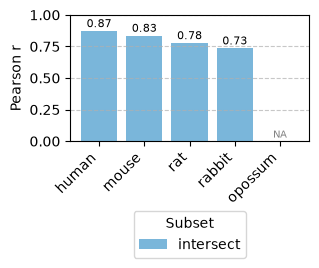

In [10]:
if subsets is None:
    sb = ["preds"]
else:
    sb = [s if str(s).startswith("preds_") else f"preds_{s}" for s in subsets]

species_list = [s for s in ['human', 'mouse', 'rat', 'rabbit', 'opossum'] if s in usage_results]
n_species = len(species_list)
n_subsets = len(sb)

fig, ax = plt.subplots(figsize=(len(species_plot) * 0.8, 3.5))

x = np.arange(n_species)
bar_width = 0.8 / max(n_subsets, 1)
colors = sns.color_palette("Blues_r", n_colors=n_subsets)

for si, subset in enumerate(sb):
    values = []
    for sp in species_list:
        sp_data = usage_results.get(sp, {})
        usage_data = sp_data.get(subset) if sp_data else None
        r = usage_data.get("overall_pearson_r", np.nan) if usage_data else np.nan
        print(f"{sp} {subset}: r={r}")
        values.append(r)

    plot_vals = [0.0 if not np.isfinite(v) else v for v in values]
    offsets = x + (si - (n_subsets - 1) / 2) * bar_width
    bars = ax.bar(offsets, plot_vals, width=bar_width, label=subset, alpha=0.9, color=colors[si])

    for bar, v in zip(bars, values):
        if np.isfinite(v):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                min(v + 0.01, 0.99),
                f"{v:.2f}",
                ha="center", va="bottom", fontsize=8
            )
        else:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                0.01,
                "NA",
                ha="center", va="bottom", fontsize=7, color="gray"
            )

ax.set_xticks(x)
ax.set_xticklabels(species_list, rotation=45, ha="right")
ax.set_ylabel("Pearson r")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.7)

ax.legend(
    [s.replace("preds_", "").replace("_protein_coding", "").replace("intersect_usage", "usage") for s in sb],
    title="Subset",
    bbox_to_anchor=(0.5, -0.5),
    loc="upper center",
    ncol=max(1, len(sb))
)

plt.tight_layout()
fig.savefig(
    os.path.join(work_dir, model, "prediction_splice_usage_correlations_overall.png"),
    dpi=300,
    bbox_inches="tight"
)


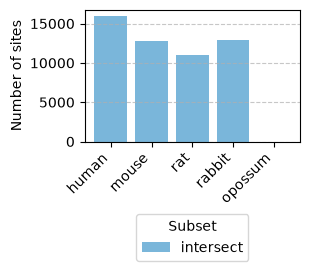

In [11]:
# Plot number of sites per species and subset
fig2, ax2 = plt.subplots(figsize=(len(species_plot) * 0.8, 3.5))


x = np.arange(n_species)
bar_width = 0.8 / max(n_subsets, 1)
colors = sns.color_palette("Blues_r", n_colors=n_subsets)

for si, subset in enumerate(sb):
    values = []
    for sp in species_list:
        sp_data = usage_results.get(sp, {})
        usage_data = sp_data.get(subset) if sp_data else None
        
        # Get total number of sites (unique across all tissues and conditions)
        if usage_data:
            per_cond = usage_data.get("per_condition", {})
            n_sites = np.median([int(v.get("n", 0)) for v in per_cond.values()])
        else:
            n_sites = 0
        values.append(n_sites)

    offsets = x + (si - (n_subsets - 1) / 2) * bar_width
    bars = ax2.bar(offsets, values, width=bar_width, label=subset, alpha=0.9, color=colors[si])


ax2.set_xticks(x)
ax2.set_xticklabels(species_list, rotation=45, ha="right")
ax2.set_ylabel("Number of sites")
ax2.grid(axis="y", linestyle="--", alpha=0.7)

ax2.legend(
    [s.replace("preds_", "").replace("_protein_coding", "").replace("intersect_usage", "usage") for s in sb],
    title="Subset",
    bbox_to_anchor=(0.5, -0.5),
    loc="upper center",
    ncol=max(1, len(sb))
)

plt.tight_layout()
fig2.savefig(
    os.path.join(work_dir, model, "prediction_splice_usage_n_sites_by_subset.png"),
    dpi=300,
    bbox_inches="tight"
)


Plot usage correlations per species and tissue

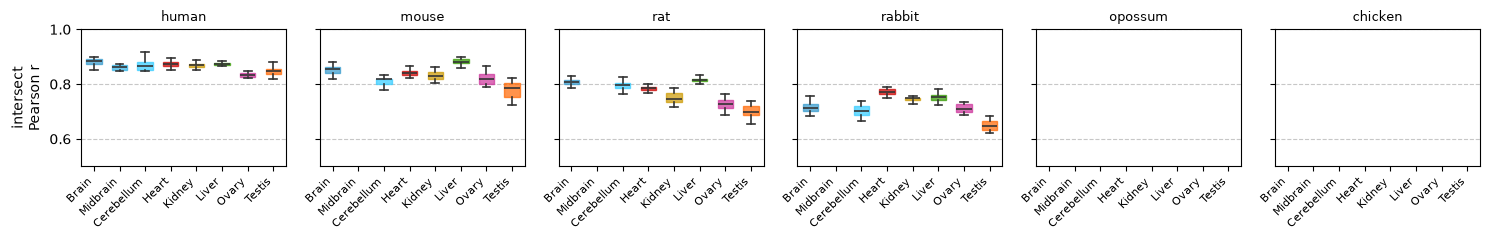

In [12]:
species_list = [s for s in SPECIES_ORDER if s in usage_results]
n_species = len(species_list)
n_subsets = len(sb)

fig, axes = plt.subplots(
    n_subsets, n_species,
    figsize=(n_species * 2.5, n_subsets * 2.5),
    sharey=True, sharex=True
)

if n_subsets == 1 and n_species == 1:
    axes = np.array([[axes]])
elif n_subsets == 1:
    axes = axes[np.newaxis, :]
elif n_species == 1:
    axes = axes[:, np.newaxis]

x = np.arange(len(TISSUE_ORDER))

ymin = 0.5
ymax = 1.0

for row, subset in enumerate(sb):
    for col, sp in enumerate(species_list):
        ax = axes[row, col]
        sp_data = usage_results.get(sp, {})
        usage_data = sp_data.get(subset) if sp_data else None
        tissue_data = usage_data.get("per_tissue", None) if usage_data else None

        if tissue_data:
            box_data = []
            positions = []
            colors = []

            for i, tissue in enumerate(TISSUE_ORDER):
                tp_dict = tissue_data.get(tissue, {}).get("timepoints", {})
                vals = [
                    tp_info.get("pearson_r", np.nan)
                    for tp_info in tp_dict.values()
                    if np.isfinite(tp_info.get("pearson_r", np.nan))
                ]

                if vals:
                    box_data.append(vals)
                    positions.append(i)
                    colors.append(TISSUE_COLORS.get(tissue, "#444444"))

            if box_data:
                bp = ax.boxplot(
                    box_data,
                    positions=positions,
                    widths=0.6,
                    patch_artist=True,
                    showfliers=False
                )

                for patch, color in zip(bp["boxes"], colors):
                    patch.set_facecolor(color)
                    patch.set_alpha(0.7)
                    patch.set_edgecolor(color)

                for element in ["whiskers", "caps", "medians"]:
                    for artist in bp[element]:
                        artist.set_color("#333333")
                        artist.set_linewidth(1.2)

        ax.set_ylim(ymin, ymax)
        ax.set_xlim(-0.5, len(TISSUE_ORDER) - 0.5)
        ax.grid(axis="y", linestyle="--", alpha=0.7)

        if row == 0:
            ax.set_title(sp, fontsize=9)
        if col == 0:
            ax.set_ylabel(f"{subset.replace("preds_", "").replace("_protein_coding", "").replace("intersect_usage", "usage")}\nPearson r", fontsize=10)

        ax.set_xticks(x)
        if row == n_subsets - 1:
            ax.set_xticklabels(TISSUE_ORDER, rotation=45, ha="right", fontsize=8)
        else:
            ax.set_xticklabels([])

plt.tight_layout()

fig.savefig(
    os.path.join(work_dir, model, "prediction_splice_usage_correlations_by_subsets.png"),
    dpi=300
)

#### Compare all models predictions

In [13]:
#models_to_compare = []
#subsets_to_compare = []

pov_model = model
pov_first = True  # If True, bars show (pov_model - other), else (other - pov_model)

usage_results_2_dict = {}

# only run if models_to_compare is not empty
if len(models_to_compare) > 0:

    for model_ in models_to_compare:
        
        if model_ == pov_model:
            continue
        model_dir_ = os.path.join(work_dir, model_)
        usage_results_ = load_splice_usage_stats(model_dir_, ann_data_dir, subsets=subsets_to_compare, species_list=[s for s in SPECIES_ORDER if s in evals and any(s in ev for ev in evals_2_dict.values())])
        usage_results_2_dict[model_] = usage_results_


    model_2_names = list(usage_results_2_dict.keys())
    n_models2 = len(model_2_names)

    species_list = [s for s in SPECIES_ORDER
                    if s in usage_results or any(s in ur2 for ur2 in usage_results_2_dict.values())]
    n_species = len(species_list)
    n_subsets = len(subsets_to_compare)

    # Collect all diffs for symmetric y-limit
    all_diffs = []
    for ur2 in usage_results_2_dict.values():
        for sp in species_list:
            for subset in subsets_to_compare:
                if subset == "preds":
                    subset_key = "preds"
                else:
                    if not subset.startswith("preds_"):
                        subset_key = "preds_" + subset
                td1 = usage_results.get(sp, {}).get(subset_key, {}).get("per_tissue", None)
                td2 = ur2.get(sp, {}).get(subset_key, {}).get("per_tissue", None)
                if not td1 or not td2:
                    continue
                for tissue in TISSUE_ORDER:
                    for tp, tp_info_1 in td1.get(tissue, {}).get("timepoints", {}).items():
                        tp_info_2 = td2.get(tissue, {}).get("timepoints", {}).get(tp)
                        if tp_info_2 is None:
                            continue
                        r1 = tp_info_1.get("pearson_r", np.nan)
                        r2 = tp_info_2.get("pearson_r", np.nan)
                        if np.isfinite(r1) and np.isfinite(r2):
                            if pov_first:
                                all_diffs.append(r1 - r2)
                        else:
                            all_diffs.append(r2 - r1)
    ylim = max(0.05, np.nanmax(np.abs(all_diffs)) * 1.15) if all_diffs else 0.2
    ylim_min, ylim_max = -ylim, ylim

    # Alternative: no y limit
    ylim_min = None
    ylim_max = None

    # Alternative: fixed y limit
    ylim_min = -0.10
    ylim_max = 0.10

    # Layout: rows = species, columns = subsets × model_2s
    n_cols = n_subsets * n_models2
    fig, axes = plt.subplots(
        n_species, n_cols,
        figsize=(max(n_cols * 2.4, 4), max(n_species * 2.2, 3.5)),
        sharey=False, sharex=True
    )
    if n_species == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_species == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]

    x = np.arange(len(TISSUE_ORDER))

    import textwrap

    def wrap_name(name, width=24):
        return "\n".join(textwrap.wrap(name, width=width))

    def short_name(name, maxlen=32):
        return name if len(name) <= maxlen else name[:maxlen - 1] + "…"

    for row, sp in enumerate(species_list):
        for col_s, subset in enumerate(subsets_to_compare):
            if subset == "preds":
                subset_key = "preds"
            else:
                if not subset.startswith("preds_"):
                    subset_key = "preds_" + subset

            for col_m, (m2_name, ur2) in enumerate(usage_results_2_dict.items()):
                col = col_s * n_models2 + col_m
                ax = axes[row, col]

                td1 = usage_results.get(sp, {}).get(subset_key, {}).get("per_tissue", None)
                td2 = ur2.get(sp, {}).get(subset_key, {}).get("per_tissue", None)

                if td1 and td2:
                    box_data, positions, colors = [], [], []
                    for i, tissue in enumerate(TISSUE_ORDER):
                        tp_dict_1 = td1.get(tissue, {}).get("timepoints", {})
                        tp_dict_2 = td2.get(tissue, {}).get("timepoints", {})
                        diffs = []
                        for tp, tp_info_1 in tp_dict_1.items():
                            tp_info_2 = tp_dict_2.get(tp)
                            if tp_info_2 is None:
                                continue
                            r1 = tp_info_1.get("pearson_r", np.nan)
                            r2 = tp_info_2.get("pearson_r", np.nan)
                            if np.isfinite(r1) and np.isfinite(r2):
                                if pov_first:
                                    diffs.append(r1 - r2)
                                else:
                                    diffs.append(r2 - r1)
                        if diffs:
                            box_data.append(diffs)
                            positions.append(i)
                            colors.append(TISSUE_COLORS.get(tissue, "#444444"))

                    if box_data:
                        bp = ax.boxplot(
                            box_data, positions=positions, widths=0.6,
                            patch_artist=True, showfliers=False
                        )
                        for patch, color in zip(bp["boxes"], colors):
                            patch.set_facecolor(color)
                            patch.set_alpha(0.7)
                            patch.set_edgecolor(color)
                        for element in ["whiskers", "caps", "medians"]:
                            for artist in bp[element]:
                                artist.set_color("#333333")
                                artist.set_linewidth(1.2)

                        # Mean across all tissues/timepoints in this subplot
                        overall_mean = np.nanmean([v for vals in box_data for v in vals])
                        ax.axhline(overall_mean, color="crimson", linewidth=1.2,
                                linestyle="--", alpha=0.8, zorder=3,
                                label=f"mean={overall_mean:+.3f}")
                        
                ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)

                if ylim_min is None or ylim_max is None:
                    # Compute symmetric limits based on data in this subplot
                    local_diffs = []
                    for line in ax.get_lines():
                        ydata = line.get_ydata()
                        local_diffs.extend(y for y in ydata if np.isfinite(y))
                    if local_diffs:
                        local_max = np.nanmax(np.abs(local_diffs)) * 1.15
                        ylim_local_min, ylim_local_max = -local_max, local_max
                        ax.set_ylim(ylim_local_min, ylim_local_max)
                else:
                    ax.set_ylim(ylim_min, ylim_max)
                    
                ax.set_xlim(-0.5, len(TISSUE_ORDER) - 0.5)
                ax.grid(axis="y", linestyle="--", alpha=0.7)

                # Column headers: "subset — model_2" on first row
                if row == 0:
                    ax.set_title(f"{wrap_name(m2_name)}", fontsize=8)
                if col == 0:
                    ax.set_ylabel(f"{sp}\nΔPearson r", fontsize=10)

                ax.set_xticks(x)
                if row == n_species - 1:
                    ax.set_xticklabels(TISSUE_ORDER, rotation=45, ha="right", fontsize=8)
                else:
                    ax.set_xticklabels([])

                # Separator between subset groups
                if col_m == 0 and col > 0:
                    ax.spines["left"].set_linewidth(1.8)
                    ax.spines["left"].set_color("black")

    model_2_label = ", ".join(model_2_names)
    if pov_first:
        plt.suptitle(f"Pearson r difference\n({model} - other)", y=1.02, fontsize=12)
    else:
        plt.suptitle(f"Pearson r difference\n(other - {model})", y=1.02, fontsize=12)
    plt.tight_layout()
    fig.savefig(
        os.path.join(work_dir, model, f"prediction_splice_usage_correlations_diff.png"),
        dpi=300, bbox_inches="tight"
    )

#### Cross-species predictions

The following evaluation is done for one subset of splice sites at a time.

In [14]:
# Make a heatmap with rows = test species, columns = prediction head species, values = usage correlation
species_plot = [s for s in SPECIES_ORDER if s in ["human", "mouse", "rat", "rabbit", "opossum", "chicken"]]
head_matrix = pd.DataFrame(np.nan, index=species_plot, columns=species_plot, dtype=float)

sci_to_sp = {v.lower(): k for k, v in SPECIES_SCI.items()}

def _map_head_key_to_species(key, test_species):
    k = str(key).strip().lower()

    # direct species names
    if k in species_plot:
        return k

    # scientific names
    if k in sci_to_sp:
        return sci_to_sp[k]

    # common prefixes/suffixes
    for prefix in ("from_", "to_", "head_"):
        if k.startswith(prefix):
            cand = k[len(prefix):]
            if cand in species_plot:
                return cand
            if cand in sci_to_sp:
                return sci_to_sp[cand]

    if k.endswith("_head"):
        cand = k[:-5]
        if cand in species_plot:
            return cand
        if cand in sci_to_sp:
            return sci_to_sp[cand]

    # same-species aliases
    if k in {"same_species", "same-species", "same", "self"}:
        return test_species

    return None


for test_species in species_plot:
    metrics_file = os.path.join(model_dir, f"{pred_dir}", test_species, "metrics.json")
    if not os.path.exists(metrics_file):
        continue

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    sp_metrics = metrics.get(test_species, {})
    usage_by_head = sp_metrics.get("usage_by_head", {}) or {}

    for head_key, head_eval in usage_by_head.items():
        head_species = _map_head_key_to_species(head_key, test_species)
        corr = head_eval.get("usage_pearson_r", np.nan) if isinstance(head_eval, dict) else np.nan
        if head_species in head_matrix.columns and np.isfinite(corr):
            head_matrix.loc[test_species, head_species] = float(corr)

# Fallback: use same-species overall correlation if diagonal is still missing
for sp in species_plot:
    if pd.isna(head_matrix.loc[sp, sp]):
        same_sp = usage_results.get(sp, {}).get(pred_dir, {}).get("overall_pearson_r", np.nan)
        if np.isfinite(same_sp):
            head_matrix.loc[sp, sp] = float(same_sp)

head_matrix

,human,mouse,rat,rabbit,opossum,chicken
human,0.871619,NaN,NaN,NaN,NaN,NaN
mouse,NaN,0.834879,NaN,NaN,NaN,NaN
rat,NaN,NaN,0.776532,NaN,NaN,NaN
rabbit,NaN,NaN,NaN,0.734652,NaN,NaN
opossum,NaN,NaN,NaN,NaN,NaN,NaN
chicken,NaN,NaN,NaN,NaN,NaN,NaN


Saved usage correlation heatmap to /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_traj_human_mouse_rat_rabbit_opossum_sasse3/preds_intersect_protein_coding/prediction_splice_usage_correlation_by_species_heatmap_preds_intersect_protein_coding.png


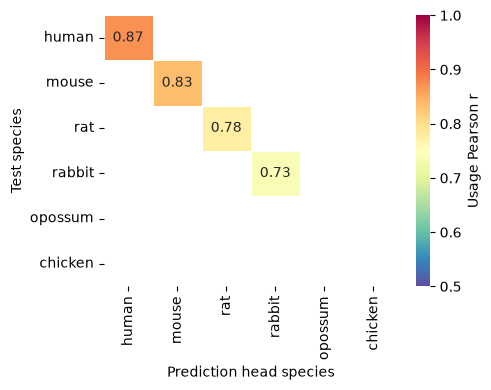

In [15]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

cmap = plt.get_cmap("Spectral_r")

norm = TwoSlopeNorm(vmin=0.5, vcenter=0.75, vmax=1.0)

plt.figure(figsize=(5, 4))
sns.heatmap(
    head_matrix,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    norm=norm,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Usage Pearson r"},
)
plt.xlabel("Prediction head species")
plt.ylabel("Test species")
plt.tight_layout()
fig_fn = os.path.join(work_dir, model, f"{pred_dir}", f"prediction_splice_usage_correlation_by_species_heatmap_{pred_dir}.png")
#plt.savefig(fig_fn, dpi=300)
print(f"Saved usage correlation heatmap to {fig_fn}")


Cross-species splice usage correlations per tissue

In [16]:
# Build per-tissue head-transfer matrices:
# rows = test species, columns = prediction head species, values = usage Pearson r

species_plot = [s for s in SPECIES_ORDER if s in ["human", "mouse", "rat", "rabbit", "opossum", "chicken"]]
tissue_matrices = {}

def _get_tissue_matrix(tissue_name):
    if tissue_name not in tissue_matrices:
        tissue_matrices[tissue_name] = pd.DataFrame(
            np.nan, index=species_plot, columns=species_plot, dtype=float
        )
    return tissue_matrices[tissue_name]

def _extract_corr(d):
    """Robustly extract a correlation value from a tissue/head metrics dict."""
    if not isinstance(d, dict):
        return np.nan
    for k in ("usage_pearson_r", "pearson_r", "mean_pearson_r", "median_pearson_r"):
        v = d.get(k, np.nan)
        if np.isfinite(v):
            return float(v)
    return np.nan

for test_species in species_plot:
    metrics_file = os.path.join(model_dir, f"{pred_dir}", test_species, "metrics.json")
    if not os.path.exists(metrics_file):
        continue

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    sp_metrics = metrics.get(test_species, {})
    per_tissue_by_head = sp_metrics.get("per_tissue_by_head", {}) or {}
    if not isinstance(per_tissue_by_head, dict):
        continue

    # Detect layout:
    # - head -> tissue -> metrics  (your current files)
    # - tissue -> head -> metrics
    n_head_like = sum(
        _map_head_key_to_species(k, test_species) is not None
        for k in per_tissue_by_head.keys()
    )
    head_first_layout = n_head_like >= max(1, len(per_tissue_by_head) // 2)

    if head_first_layout:
        # Case: head -> tissue -> metrics
        for head_key, tissue_map in per_tissue_by_head.items():
            if not isinstance(tissue_map, dict):
                continue
            head_species = _map_head_key_to_species(head_key, test_species)
            if head_species is None:
                continue

            for tissue, tissue_eval in tissue_map.items():
                corr = _extract_corr(tissue_eval)
                if np.isfinite(corr):
                    mat = _get_tissue_matrix(tissue)
                    if head_species in mat.columns:
                        mat.loc[test_species, head_species] = corr
    else:
        # Case: tissue -> head -> metrics
        for tissue, head_map in per_tissue_by_head.items():
            if not isinstance(head_map, dict):
                continue
            mat = _get_tissue_matrix(tissue)
            for head_key, head_eval in head_map.items():
                head_species = _map_head_key_to_species(head_key, test_species)
                corr = _extract_corr(head_eval)
                if head_species in mat.columns and np.isfinite(corr):
                    mat.loc[test_species, head_species] = corr

# Fallback: fill missing diagonal from same-species per_tissue in usage_results
for tissue, mat in tissue_matrices.items():
    for sp in species_plot:
        if pd.isna(mat.loc[sp, sp]):
            v = (
                usage_results.get(sp, {})
                .get(pred_dir, {})
                .get("per_tissue", {})
                .get(tissue, {})
                .get("pearson_r", np.nan)
            )
            if np.isfinite(v):
                mat.loc[sp, sp] = float(v)

# Order tissues (known first, then any extras like Midbrain)
ordered_tissues = [t for t in TISSUE_ORDER if t in tissue_matrices] + [
    t for t in tissue_matrices if t not in TISSUE_ORDER
]
tissue_matrices = {t: tissue_matrices[t] for t in ordered_tissues}

for tissue, mat in tissue_matrices.items():
    print(f"\n{tissue}")
    display(mat)

In [17]:
# Plot per-tissue cross-species usage correlation matrices as heatmaps

if not tissue_matrices:
    print("tissue_matrices is empty.")
else:
    # Reuse colormap/norm from earlier heatmap cell if present
    _cmap = cmap if "cmap" in globals() else "coolwarm"
    _norm = norm if "norm" in globals() else None

    tissues_to_plot = [t for t in TISSUE_ORDER if t in tissue_matrices] + [
        t for t in tissue_matrices if t not in TISSUE_ORDER
    ]

    n_tissues = len(tissues_to_plot)
    n_cols = min(4, n_tissues)
    n_rows = int(np.ceil(n_tissues / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 4.2, n_rows * 3.8),
        squeeze=False
    )
    axes = axes.ravel()

    for i, tissue in enumerate(tissues_to_plot):
        ax = axes[i]
        mat = tissue_matrices[tissue]

        sns.heatmap(
            mat,
            ax=ax,
            annot=True,
            fmt=".3f",
            cmap=_cmap,
            norm=_norm,
            vmin=None if _norm is not None else 0.0,
            vmax=None if _norm is not None else 1.0,
            linewidths=0.5,
            linecolor="white",
            cbar=(i == 0),
            cbar_kws={"label": "Usage Pearson r"} if i == 0 else None
        )

        ax.set_title(tissue, fontsize=11)
        ax.set_xlabel("Prediction head species")
        ax.set_ylabel("Test species")

    # Hide unused axes
    for j in range(n_tissues, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()

    out_fn = os.path.join(
        work_dir,
        model,
        f"{pred_dir}",
        f"prediction_splice_usage_correlation_by_species_heatmap_per_tissue_{pred_dir}.png"
    )
    fig.savefig(out_fn, dpi=300, bbox_inches="tight")
    print(f"Saved tissue heatmaps to {out_fn}")
    

tissue_matrices is empty.


## Parse splice site classification predictions

Load splice site classification predictions and labels for each species and subset.

In [18]:
%%time
import os
import json

save = True
class_results = {}

if pred_dir.startswith("preds"):
    pd_key = pred_dir
else:
    pd_key = "preds_" + pred_dir
data_dir = os.path.join(work_dir, model, f"{pd_key}")
print(f"Data directory for predictions: {data_dir}")

class_keys = SPLICE_CLASS_NAMES + ["binary"]

for species in ["human", "mouse", "rat", "rabbit", "opossum"]: 

    if species not in class_results:
        
        class_results[species] = {}
        
        # Load predictions
        pred_file = os.path.join(data_dir, species, f"predictions_{species}.npz")
        if os.path.exists(pred_file):
            preds = np.load(pred_file)
        else:
            print(f"Predictions for {species} in {pd_key} are missing ({pred_file}).")
            continue        
        print(f"Loaded predictions for {species}")

        # Load genomic intervals for each prediction
        bed_file = os.path.join(data_dir, species, f"sampled_windows_{species}.bed")
        if os.path.exists(bed_file):
            bed_df = pd.read_csv(bed_file, sep="\t", index_col=False, header=None, names=["chrom", "start", "end", "strand", "mask_rel_start", "mask_rel_end"])
            bed_df['mask_start'] = bed_df['start'] + bed_df['mask_rel_start']
            bed_df['mask_end'] = bed_df['start'] + bed_df['mask_rel_end']
        else:
            print(f"BED file for {species} in {pd_key} is missing.")
            continue
        
        # Build a dataframe with one row per position in each chrom:mask_start-mask_end interval
        true_cls = preds['cls_labels']
        cls_probs = preds['cls_probs']
        rows = []
        for _, row in bed_df.iterrows():
            for pos in range(row['mask_start'], row['mask_end']):
                rows.append({'chrom': row['chrom'], 'position': pos})

        positions_df = pd.DataFrame(rows)

        # Check that positions_df has the same number of rows as the total number of elements in preds['cls_probs']
        assert len(positions_df) == true_cls.shape[0], f"Mismatch between positions dataframe ({len(positions_df)}) and predictions array length ({preds['cls_probs'].shape[0]})"

        # Add true labels
        positions_df['class_label'] = true_cls

        # Add predicted probabilities for each class
        for i, class_name in enumerate(class_keys):
            positions_df[f'prob_{i}'] = cls_probs[:, i]

        # Add predicted class based on highest probability
        positions_df['predicted_class_label'] = positions_df[[f'prob_{i}' for i in range(len(class_keys))]].idxmax(axis=1).apply(lambda x: int(x.split('_')[1]))

        print(f"Collected {positions_df.shape[0]} positions for {species} into dataframe")

        # Save to disk
        if save:
            pq_file = os.path.join(work_dir, model, pd_key, species, f"predictions_{species}.parquet")
            positions_df.to_parquet(pq_file, index=False)
            print(f"Saved predictions for {species} to parquet: {pq_file}")

        class_results[species] = positions_df

class_results 

Data directory for predictions: /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_traj_human_mouse_rat_rabbit_opossum_sasse3/preds_intersect_protein_coding
Loaded predictions for human
Collected 63665914 positions for human into dataframe
Saved predictions for human to parquet: /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_traj_human_mouse_rat_rabbit_opossum_sasse3/preds_intersect_protein_coding/human/predictions_human.parquet
Loaded predictions for mouse
Collected 45598359 positions for mouse into dataframe
Saved predictions for mouse to parquet: /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_traj_human_mouse_rat_rabbit_opossum_sasse3/preds_intersect_protein_coding/mouse/predictions_mouse.parquet
Loaded predictions for rat
Collected 38565256 positions for rat into dataframe
Saved predictions for rat to parquet: /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_traj_human_mouse_rat_rabbit_opossum_sasse3/preds_inters

{'human':          chrom  position  class_label    prob_0    prob_1    prob_2    prob_3  \
 0            1   1535174            4  0.000067  0.000330  0.005707  0.000111   
 1            1   1535175            4  0.000027  0.000043  0.000026  0.000032   
 2            1   1535176            4  0.000027  0.000063  0.000039  0.000021   
 3            1   1535177            4  0.000063  0.000103  0.000046  0.000042   
 4            1   1535178            4  0.000050  0.000126  0.000021  0.000046   
 ...        ...       ...          ...       ...       ...       ...       ...   
 63665909     Y  21549321            4  0.002335  0.000309  0.003769  0.000317   
 63665910     Y  21549322            4  0.000292  0.000009  0.000033  0.000162   
 63665911     Y  21549323            4  0.000041  0.000145  0.000062  0.000049   
 63665912     Y  21549324            4  0.000072  0.000028  0.000195  0.000064   
 63665913     Y  21549325            4  0.001266  0.000028  0.000077  0.000159   
 
     

## Parse splice usage predictions

Load splice usage predictions and condition labels for each species and subset.

In [20]:
%%time
usage_results = {}

for sps in SPECIES_ORDER:
    usage_results[sps] = {}

    # Load condition metadata: maps condition index -> "Tissue_Timepoint" label
    metadata_file = os.path.join(ann_data_dir, SPECIES_SCI[sps], "usage.json")
    if not os.path.exists(metadata_file):
        print(f"Metadata missing for {sps}: {metadata_file}")
        continue
    with open(metadata_file) as f:
        metadata = json.load(f)
    idx_to_label = {int(v): k for k, v in metadata.get("condition_labels", {}).items()}

    if pred_dir.startswith("preds"):
        pd_key = pred_dir
    else:
        pd_key = "preds_" + pred_dir
    usage_file = os.path.join(work_dir, model, f"{pd_key}", sps, f"usage_{sps}.npz")
    if not os.path.exists(usage_file):
        print(f"  Usage file missing: {sps} / {pd_key}")
        usage_results[sps][pd_key] = None
        continue

    data = np.load(usage_file)
    chr_pos    = data["chr_pos"]
    cond_ids   = data["cond_ids"]
    trues      = data["true"]
    preds      = data["pred"]

    # Split condition labels into Tissue and Timepoint
    tissues = []        
    timepoints = []
    for cond_id in cond_ids:
        tissue, timepoint = idx_to_label[cond_id].split("_")
        tissues.append(tissue)
        timepoints.append(timepoint)

    usage_results[sps] = {
        "chr_pos": chr_pos,
        "cond_ids": cond_ids,
        "tissues": tissues,
        "timepoints": timepoints,
        "trues": trues,
        "preds": preds,
        "idx_to_label": idx_to_label
    }

  Usage file missing: chicken / preds_intersect_protein_coding
CPU times: user 1.34 s, sys: 229 ms, total: 1.57 s
Wall time: 27.9 s


In [21]:
%%time
# Backup mechanism: save usage_<species>.parquet from usage_<species>.npz.
# scripts/evaluate_splice.py now writes this parquet directly during evaluation, so this
# cell is only needed to backfill it for older/previously generated npz-only predictions.
save = True
overwrite = False

if pred_dir.startswith("preds"):
    pd_key = pred_dir
else:
    pd_key = "preds_" + pred_dir

for sps, data in usage_results.items():
    if not isinstance(data, dict) or "chr_pos" not in data:
        print(f"No usage predictions loaded for {sps}, skipping.")
        continue

    out_fn = os.path.join(work_dir, model, pd_key, sps, f"usage_{sps}.parquet")
    if os.path.exists(out_fn) and not overwrite:
        print(f"Usage parquet already exists for {sps}, skipping ({out_fn}).")
        continue

    usage_df = pd.DataFrame({
        "chr_pos": data["chr_pos"],
        "cond_ids": data["cond_ids"],
        "SSE_true": data["trues"],
        "SSE_pred": data["preds"],
    })
    usage_df["Species"] = sps
    usage_df["Chromosome"] = usage_df["chr_pos"].apply(lambda x: x.split(":")[0])
    usage_df["Position"] = usage_df["chr_pos"].apply(lambda x: int(x.split(":")[1]))

    idx_to_label = data["idx_to_label"]
    usage_df["Condition_Name"] = usage_df["cond_ids"].map(idx_to_label).fillna("None_0")
    split = usage_df["Condition_Name"].str.rsplit("_", n=1, expand=True)
    usage_df["Tissue"] = split[0]
    usage_df["Timepoint"] = split[1].astype(int)

    usage_df = usage_df[["Species", "Chromosome", "Position", "SSE_true", "SSE_pred",
                          "Condition_Name", "Tissue", "Timepoint"]]

    print(f"Collected {usage_df.shape[0]:,} usage rows for {sps}")

    if save:
        os.makedirs(os.path.dirname(out_fn), exist_ok=True)
        usage_df.to_parquet(out_fn, index=False)
        print(f"Saved usage predictions for {sps} to parquet: {out_fn}")

Collected 1,305,511 usage rows for human
Saved usage predictions for human to parquet: /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_traj_human_mouse_rat_rabbit_opossum_sasse3/preds_intersect_protein_coding/human/usage_human.parquet
Collected 1,172,874 usage rows for mouse
Saved usage predictions for mouse to parquet: /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_traj_human_mouse_rat_rabbit_opossum_sasse3/preds_intersect_protein_coding/mouse/usage_mouse.parquet
Collected 984,234 usage rows for rat
Saved usage predictions for rat to parquet: /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_traj_human_mouse_rat_rabbit_opossum_sasse3/preds_intersect_protein_coding/rat/usage_rat.parquet
Collected 1,174,648 usage rows for rabbit
Saved usage predictions for rabbit to parquet: /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_traj_human_mouse_rat_rabbit_opossum_sasse3/preds_intersect_protein_coding/rabbit/usage_rabbit.pa